# SIV Project: Board Game Analysis — Score Tracking
**Students:** Federico Berra and Davide Verzotto

## 1. Environment Setup & Tools

In [84]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

try:
    from cv2.xfeatures2d import matchGMS
    HAS_GMS = True
except (ImportError, AttributeError):
    if hasattr(cv2, "matchGMS"):          
        matchGMS = cv2.matchGMS
        HAS_GMS = True
    else:
        HAS_GMS = False
        print("ATTENZIONE: matchGMS non disponibile -> uso il ratio test di Lowe.")


def show_image(img, title="Image", cmap=None):
    plt.figure(figsize=(10, 8))
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

print("Setup Complete. Tools are ready!")

Setup Complete. Tools are ready!


## 2. Selezione manuale dei corner (utility una tantum)

In [85]:
def pick_points(image_path):
    """Apre l'immagine e raccoglie i punti cliccati (chiudi con un tasto qualsiasi)."""
    img = cv2.imread(image_path)
    points = []

    def click_event(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            points.append((x, y))
            print("Clicked:", x, y)

    cv2.imshow("image", img)
    cv2.setMouseCallback("image", click_event)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    return points

folder_path = "../dataset/Game_2/"
files = sorted(f for f in os.listdir(folder_path)
               if f.lower().endswith((".png", ".jpg", ".jpeg")))
print("Primo frame:", files[0])   

pts = pick_points(os.path.join(folder_path, files[0]))
print("Punti cliccati:", pts)

Primo frame: 001.png
Clicked: 404 134
Clicked: 1520 132
Clicked: 1518 871
Clicked: 410 879
Punti cliccati: [(404, 134), (1520, 132), (1518, 871), (410, 879)]


## 3. Immagini di riferimento rettificate
Il riferimento del tabellone vuoto definisce il **sistema di coordinate comune** in cui vengono portati tutti i frame. La geometria del tracciato (sezione 5) è definita in queste coordinate.

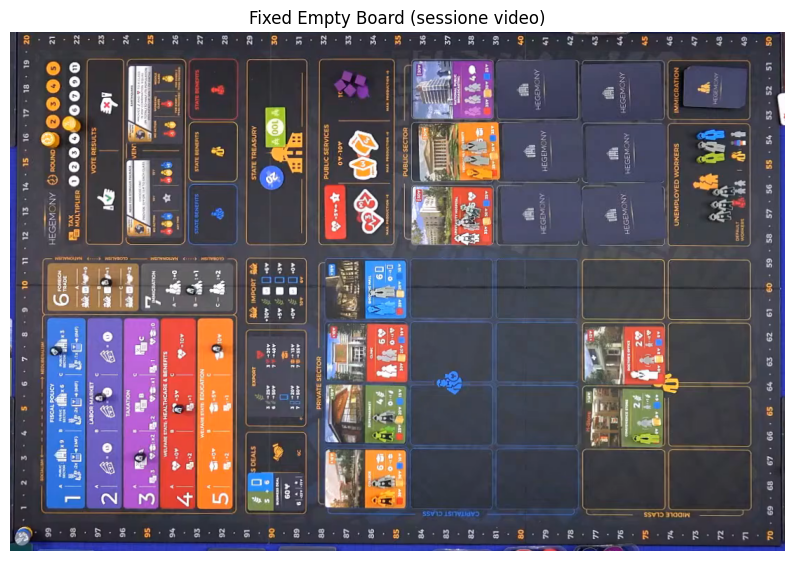

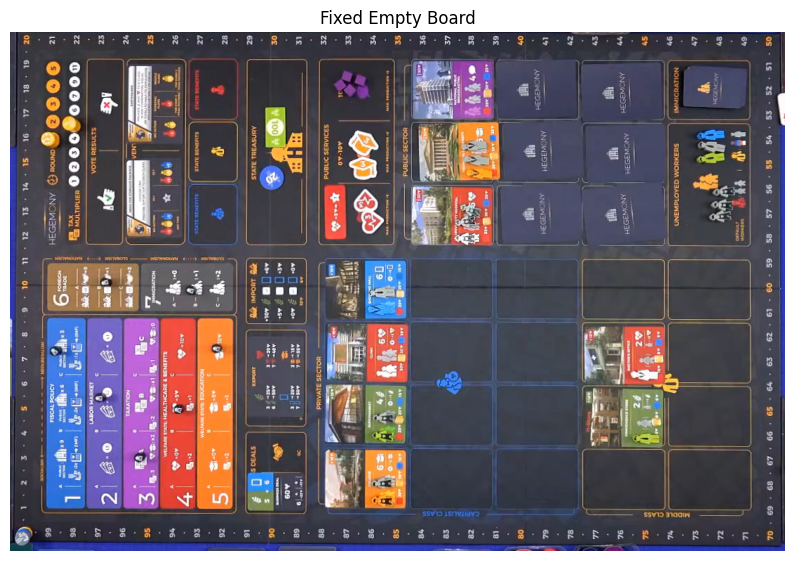

In [86]:
def rotate_left(image):
    return cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)


def build_reference(image_path, src_pts, dst_size, dst_pts):
    raw = cv2.imread(image_path)
    if raw is None:
        raise FileNotFoundError(image_path)
    M = cv2.getPerspectiveTransform(np.float32(src_pts), np.float32(dst_pts))
    return cv2.warpPerspective(raw, M, dst_size)


# --- Tabellone completo ---
BoardW, BoardH = 1105, 740
fixed_emptyBoard = build_reference(
    "../dataset/Game_2/001.png",
    [[404, 134], [1520, 132], [1518, 871], [410, 879]],   
    (BoardW, BoardH),
    [[0, 0], [BoardW - 1, 0], [BoardW - 1, BoardH - 1], [0, BoardH - 1]],
)
show_image(fixed_emptyBoard, "Fixed Empty Board (sessione video)")

# --- Sezione "politics" ---
PoliticW, PoliticH = 1140, 870
fixed_politics_section = build_reference(
    "../dataset/empty_board/politics.jpg",
    [[68, 64], [928, 94], [74, 1211], [938, 1186]],
    (PoliticW, PoliticH),
    [[0, PoliticH - 1], [0, 0], [PoliticW - 1, PoliticH - 1], [PoliticW - 1, 0]],
)
fixed_politics_section = rotate_left(fixed_politics_section)

# --- Prima meta' del tabellone ---
firstHalfW, firstHalfH = 950, 1250
fixed_first_half = build_reference(
    "../dataset/empty_board/first_half.jpg",
    [[959, 74], [4, 18], [2, 1252], [947, 1256]],
    (firstHalfW, firstHalfH),
    [[0, firstHalfH - 1], [firstHalfW - 1, firstHalfH - 1], [firstHalfW - 1, 0], [0, 0]],
)

show_image(fixed_emptyBoard, "Fixed Empty Board")


# --- Geometria del tracciato (usata anche dall'allineamento ECC) ---
BORDERS = (55, 54, 40, 38)   # top, bottom, left, right

def build_ring_mask(w, h, borders):
    bt, bb, bl, br = borders
    mask = np.zeros((h, w), dtype=np.uint8)
    mask[0:bt, :] = 255
    mask[h - bb:h, :] = 255
    mask[:, 0:bl] = 255
    mask[:, w - br:w] = 255
    return mask

ring_mask = build_ring_mask(BoardW, BoardH, BORDERS)

## 4. Localizzazione via omografia e allineamento esatto
`align_to_reference` è la funzione chiave del progetto: porta il frame di gioco **pixel per pixel** nelle stesse coordinate del riferimento vuoto (stessa dimensione, stesso allineamento). Questo è indispensabile per la differenza della sezione 6: se le immagini non coincidono al pixel, i numeri stampati non si cancellano.

In [87]:
def findImage(imageToFind, WholeImage, show_matches=False):
    """Trova 'imageToFind' (riferimento) dentro 'WholeImage' e riproietta
    WholeImage nel sistema di coordinate del riferimento."""
    orb = cv2.ORB_create(nfeatures=5000)
    kp1, des1 = orb.detectAndCompute(imageToFind, None)
    kp2, des2 = orb.detectAndCompute(WholeImage, None)

    if des1 is None or des2 is None:
        return None

    if HAS_GMS:
        matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
        matches = matcher.match(des1, des2)
        good = matchGMS(
            imageToFind.shape[:2], WholeImage.shape[:2],
            kp1, kp2, matches,
            withRotation=False, withScale=True, thresholdFactor=6,
        )
    else:
        matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
        knn = matcher.knnMatch(des1, des2, k=2)
        good = [m for m, n in knn if m.distance < 0.75 * n.distance]

    if len(good) < 4:
        return None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)
    if H is None:
        return None

    if show_matches:
        inliers = [m for m, keep in zip(good, mask.ravel().astype(bool)) if keep]
        show_image(
            cv2.drawMatches(imageToFind, kp1, WholeImage, kp2, inliers, None,
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS),
            "Inlier Matches",
        )

    out_size = (imageToFind.shape[1], imageToFind.shape[0])
    return cv2.warpPerspective(WholeImage, H, out_size)


def findPart(referenceSections, completeImage, show_matches=False):
    for ref in referenceSections:
        result = findImage(ref, completeImage, show_matches=show_matches)
        if result is None:
            print("Localizzazione fallita su uno step della cascata.")
            return completeImage
        completeImage = result
    return completeImage


def crop_image(image, pLeft, pRight, pTop, pBottom):
    height, width = image.shape[:2]
    return image[int(height * pTop): height - int(height * pBottom),
                 int(width * pLeft): width - int(width * pRight)]


def crop_half2politics(image):
    return crop_image(image, 0.0, 0.30, 0.35, 0.0)


def refine_with_ecc(aligned, ref, mask=None, gauss=5):
    g_ref = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)
    g_img = cv2.cvtColor(aligned, cv2.COLOR_BGR2GRAY)
    warp = np.eye(3, 3, dtype=np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 300, 1e-6)
    try:
        cc, warp = cv2.findTransformECC(g_ref, g_img, warp,
                                        cv2.MOTION_HOMOGRAPHY, criteria,
                                        mask, gauss)
    except cv2.error:
        return aligned
    return cv2.warpPerspective(aligned, warp,
                               (ref.shape[1], ref.shape[0]),
                               flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)



def locate_politics(frame):
    out = findPart([fixed_emptyBoard, fixed_first_half], frame)
    out = crop_half2politics(out)
    return findPart([fixed_politics_section], out)


def find_board_corners(frame, debug=False):
    """Trova i 4 angoli del tabellone (quadrilatero scuro più grande)."""
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    # il tavolo è blu/chiaro, il tabellone scuro: maschera per bassa luminosità
    dark = cv2.inRange(hsv, (0, 0, 0), (180, 255, 110))
    dark = cv2.morphologyEx(dark, cv2.MORPH_CLOSE, np.ones((25, 25), np.uint8))
    dark = cv2.morphologyEx(dark, cv2.MORPH_OPEN,  np.ones((15, 15), np.uint8))
    if debug:
        show_image(dark, "Maschera tabellone", cmap='gray')

    contours, _ = cv2.findContours(dark, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    board = max(contours, key=cv2.contourArea)
    if cv2.contourArea(board) < 0.15 * frame.shape[0] * frame.shape[1]:
        return None   # troppo piccolo: probabilmente non è il tabellone

    peri = cv2.arcLength(board, True)
    for eps in (0.02, 0.03, 0.05):
        approx = cv2.approxPolyDP(board, eps * peri, True)
        if len(approx) == 4:
            return approx.reshape(4, 2).astype(np.float32)
    return None


def order_corners(pts):
    """Ordina i 4 punti: alto-sx, alto-dx, basso-dx, basso-sx."""
    s = pts.sum(axis=1); d = np.diff(pts, axis=1).ravel()
    return np.float32([pts[np.argmin(s)], pts[np.argmin(d)],
                       pts[np.argmax(s)], pts[np.argmax(d)]])


def align_to_reference(frame):
    """Prova sia angoli sia ORB, raffina con ECC, tiene il risultato migliore.
    Restituisce None se nessun allineamento e' credibile."""
    candidates = []

    corners = find_board_corners(frame)
    if corners is not None:
        src = order_corners(corners)
        dst = np.float32([[0, 0], [BoardW - 1, 0],
                          [BoardW - 1, BoardH - 1], [0, BoardH - 1]])
        M = cv2.getPerspectiveTransform(src, dst)
        candidates.append(cv2.warpPerspective(frame, M, (BoardW, BoardH)))

    orb_coarse = findImage(fixed_emptyBoard, frame)
    if orb_coarse is not None:
        candidates.append(orb_coarse)

    best, best_score = None, -1.0
    for c in candidates:
        out = refine_with_ecc(c, fixed_emptyBoard, mask=ring_mask, gauss=21)
        out = refine_with_ecc(out, fixed_emptyBoard, mask=ring_mask, gauss=5)
        s = alignment_score(out, fixed_emptyBoard)
        if s > best_score:
            best, best_score = out, s

    print(f"[align] score = {best_score:.2f}")   # utile in taratura, poi si puo' togliere
    return best if best_score > 0.35 else None


def alignment_score(out, ref):
    """Correlazione col riferimento nella fascia del tracciato (1 = perfetto)."""
    g1 = cv2.cvtColor(out, cv2.COLOR_BGR2GRAY)[ring_mask > 0].astype(np.float32)
    g2 = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)[ring_mask > 0].astype(np.float32)
    return np.corrcoef(g1, g2)[0, 1]

### Test di allineamento su un frame

Loaded: 003.png
[align] score = 0.94


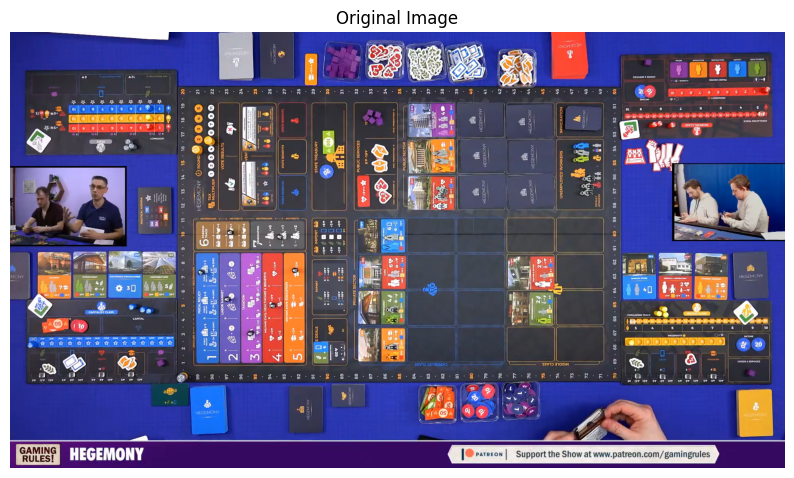

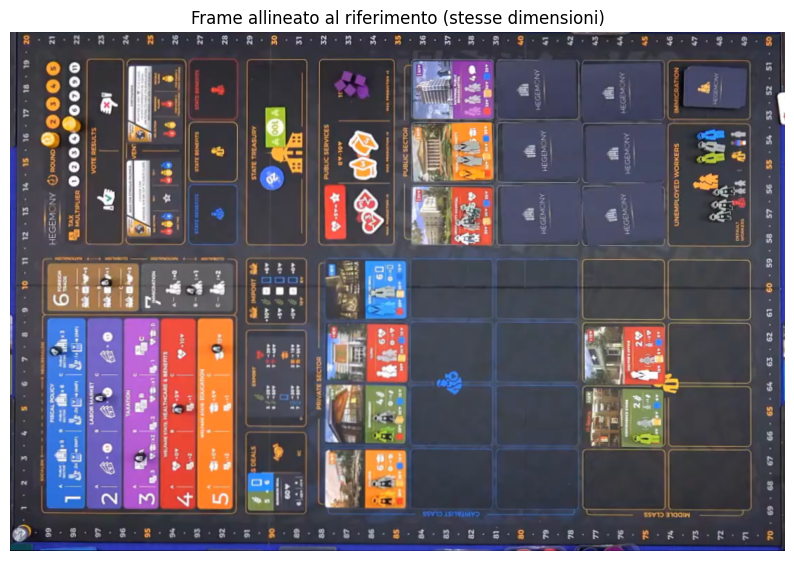

In [89]:
folder_path = "../dataset/Game_2/"
image_name = sorted(os.listdir(folder_path))[2]
img = cv2.imread(os.path.join(folder_path, image_name))
print("Loaded:", image_name)

aligned = align_to_reference(img)
if aligned is None:
    raise RuntimeError("Allineamento fallito su questo frame")

show_image(img, "Original Image")
show_image(aligned, "Frame allineato al riferimento (stesse dimensioni)")

## 5. Modello del tracciato punteggi (costruito una sola volta)
Il tracciato 0–99 corre lungo il perimetro: le caselle sono equispaziate su ogni lato, quindi le loro posizioni si calcolano geometricamente nelle coordinate del riferimento. Sul tabellone Hegemony la disposizione è:

- **bordo inferiore** (da sinistra a destra): 0, 99, 98, …, 70
- **bordo sinistro** (dal basso verso l'alto): 1 … 19
- **bordo superiore** (da sinistra a destra): 20 … 50
- **bordo destro** (dall'alto verso il basso): 51 … 69

**Verifica con l'overlay qui sotto:** ogni numero disegnato deve cadere sulla casella corrispondente del tabellone vuoto. Se qualcosa non coincide, ritoccare `BORDERS` (spessore della fascia) o le liste dei punteggi per lato.

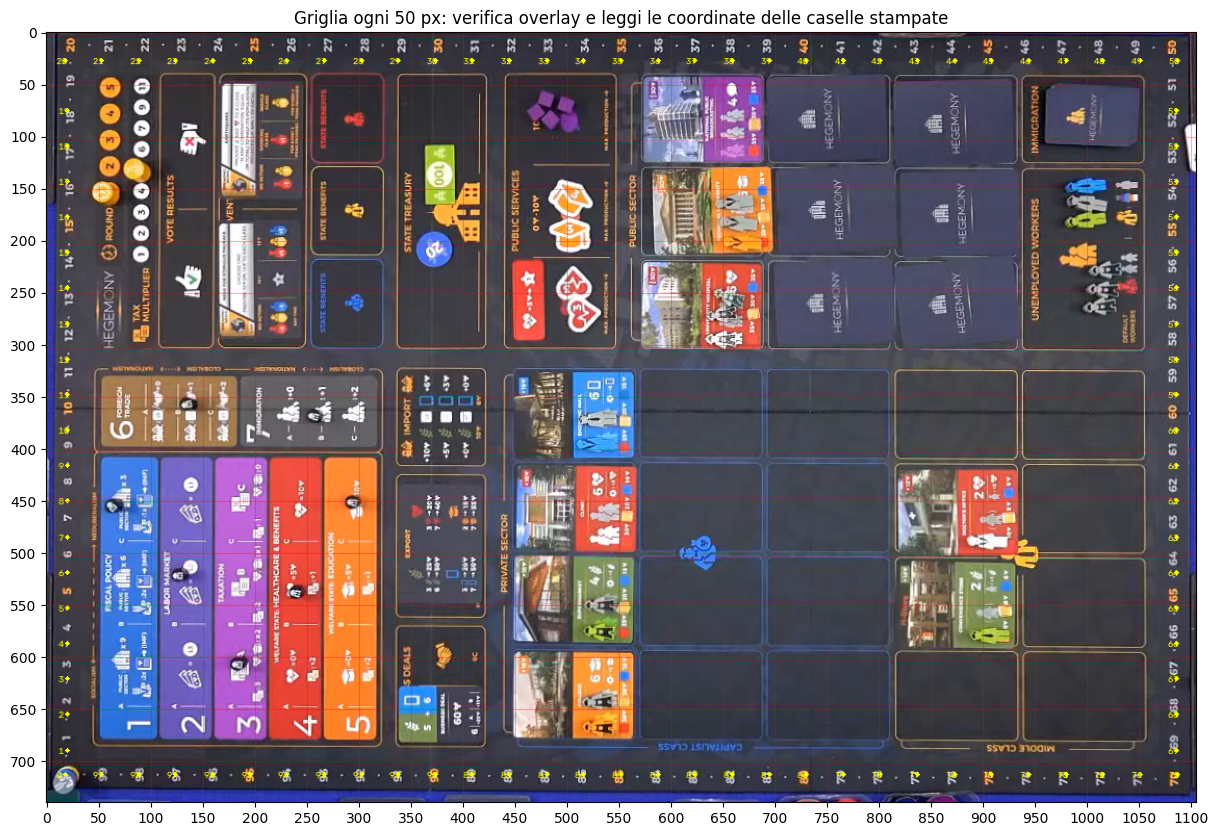

In [90]:
# ============ CONFIGURAZIONE TRACCIATO ============
SCORES_BOTTOM = [0] + list(range(99, 69, -1))   # 31 caselle, da sinistra a destra
SCORES_LEFT   = list(range(1, 20))              # 19 caselle, dal basso verso l'alto
SCORES_TOP    = list(range(20, 51))             # 31 caselle, da sinistra a destra
SCORES_RIGHT  = list(range(51, 70))             # 19 caselle, dall'alto verso il basso

# ---- CALIBRAZIONE: coordinate dei centri delle caselle agli estremi di ogni lato ----
# Leggi questi 8 valori dalla griglia rossa (precisione +/-5 px) e sostituiscili.
x20, x50 = 18, 1087     # bordo ALTO
x0,  x70 = 18, 1087     # bordo BASSO
y1,  y19 = 690, 75      # bordo SINISTRO
y51, y69 = 75, 690      # bordo DESTRO
# -------------------------------------------------------------------------------------


def span_from_centers(c_first, c_last, n):
    """Span tale che la prima e l'ultima casella cadano esattamente su c_first e c_last."""
    d = (c_last - c_first) / (n - 1)
    return (c_first - d / 2, c_last + d / 2)


SPAN_TOP    = span_from_centers(x20, x50, len(SCORES_TOP))
SPAN_BOTTOM = span_from_centers(x0,  x70, len(SCORES_BOTTOM))
SPAN_LEFT   = span_from_centers(y1,  y19, len(SCORES_LEFT))
SPAN_RIGHT  = span_from_centers(y51, y69, len(SCORES_RIGHT))


def _spread(scores, span, fixed_coord, axis):
    a, b = span
    n = len(scores)
    out = {}
    for i, s in enumerate(scores):
        pos = int(a + (i + 0.5) * (b - a) / n)
        out[s] = (pos, fixed_coord) if axis == "x" else (fixed_coord, pos)
    return out


def build_track_model(w, h, borders):
    bt, bb, bl, br = borders
    cells = {}
    cells.update(_spread(SCORES_BOTTOM, SPAN_BOTTOM, h - bb // 2, "x"))
    cells.update(_spread(SCORES_LEFT,   SPAN_LEFT,   bl // 2,      "y"))
    cells.update(_spread(SCORES_TOP,    SPAN_TOP,    bt // 2,      "x"))
    cells.update(_spread(SCORES_RIGHT,  SPAN_RIGHT,  w - br // 2,  "y"))
    return cells


track_cells = build_track_model(BoardW, BoardH, BORDERS)

# --- Overlay di verifica con griglia per la calibrazione ---
overlay = fixed_emptyBoard.copy()
for score, (x, y) in track_cells.items():
    cv2.circle(overlay, (x, y), 2, (0, 255, 255), -1)
    cv2.putText(overlay, str(score), (x - 8, y + 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 255), 1)

plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.xticks(range(0, BoardW, 50))
plt.yticks(range(0, BoardH, 50))
plt.grid(True, color='red', alpha=0.3)
plt.title("Griglia ogni 50 px: verifica overlay e leggi le coordinate delle caselle stampate")
plt.show()

## 6. Rilevamento dei dischi segnapunti (differenza col tabellone vuoto)
Dentro la fascia del tracciato calcoliamo la differenza tra frame allineato e riferimento vuoto: la grafica stampata si cancella, i dischi (e le mani) emergono. I blob vengono filtrati per dimensione e classificati per colore (HSV) per capire a quale classe appartengono.

Con `debug=True` vengono stampati area, dimensioni e HSV di ogni candidato: usali per tarare le soglie qui sotto sulla tua immagine.

In [91]:
# ============ PARAMETRI DETECTION ============
DIFF_THRESHOLD  = 40     # soglia sulla differenza (0-255)
MIN_TOKEN_AREA  = 60     # area minima blob (px^2)
MAX_TOKEN_AREA  = 2000   # area massima blob
MAX_TOKEN_SIZE  = 60     # lato massimo del bounding box (anti mano/braccio)
# =============================================

# Riferimento pre-sfocato una sola volta (riduce il rumore della differenza)
_empty_blur = cv2.GaussianBlur(fixed_emptyBoard, (5, 5), 0)


def classify_token_color(hsv):
    """Classifica un colore mediano HSV nella classe di gioco."""
    H, S, V = int(hsv[0]), int(hsv[1]), int(hsv[2])
    if S < 60 and V > 110:
        return "State"
    if S >= 60 and V >= 80:          
        if H <= 10 or H >= 165:
            return "Working"
        if 15 <= H <= 40:
            return "Middle"
        if 90 <= H <= 135:           
            return "Capitalist"
    return None


def detect_score_tokens(aligned, debug=False):
    """Trova i dischi segnapunti nella fascia del tracciato.
    Ritorna lista di dict: {class, score, center, area}."""
    frame_blur = cv2.GaussianBlur(aligned, (5, 5), 0)

    # Differenza per canale -> massimo sui canali
    diff = cv2.absdiff(frame_blur, _empty_blur)
    diff_gray = diff.max(axis=2).astype(np.uint8)
    diff_gray = cv2.bitwise_and(diff_gray, ring_mask)

    _, binary = cv2.threshold(diff_gray, DIFF_THRESHOLD, 255, cv2.THRESH_BINARY)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  np.ones((3, 3), np.uint8))

    if debug:
        show_image(binary, "Debug: maschera differenza nel tracciato", cmap='gray')

    hsv_img = cv2.cvtColor(aligned, cv2.COLOR_BGR2HSV)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    tokens = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if not (MIN_TOKEN_AREA < area < MAX_TOKEN_AREA):
            continue
        x, y, bw, bh = cv2.boundingRect(cnt)
        if bw > MAX_TOKEN_SIZE or bh > MAX_TOKEN_SIZE:
            continue  # mani, braccia, ombre estese

        M = cv2.moments(cnt)
        if M["m00"] == 0:
            continue
        cX, cY = int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])

        # Colore mediano in una patch 7x7 attorno al centroide
        y0, y1 = max(cY - 3, 0), min(cY + 4, aligned.shape[0])
        x0, x1 = max(cX - 3, 0), min(cX + 4, aligned.shape[1])
        patch = hsv_img[y0:y1, x0:x1].reshape(-1, 3)
        hsv_med = np.median(patch, axis=0)

        cls = classify_token_color(hsv_med)

        # Casella piu' vicina
        score = min(track_cells,
                    key=lambda s: (track_cells[s][0] - cX) ** 2 + (track_cells[s][1] - cY) ** 2)

        if debug:
            print(f"blob area={area:5.0f} box={bw}x{bh} HSV={hsv_med.astype(int)} "
                  f"-> classe={cls} casella={score}")

        if cls is not None:
            tokens.append({"class": cls, "score": score, "center": (cX, cY), "area": area})

    return tokens

## 7. Lettura del punteggio su un singolo frame
Ogni classe ha **un solo** disco sul tracciato: se la detection ne trova più di uno (rumore), teniamo quello con area maggiore.

[align] score = 0.94


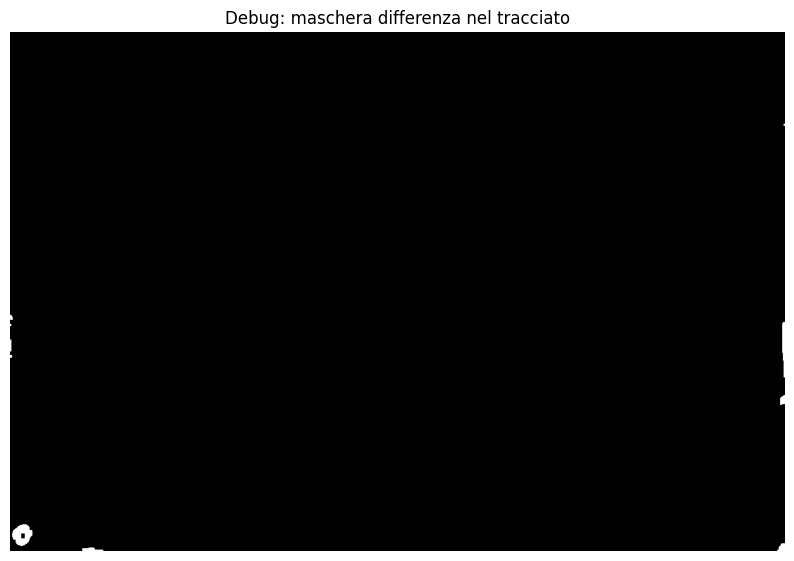

blob area=   72 box=30x5 HSV=[110 186 203] -> classe=Capitalist casella=97
blob area=   72 box=11x11 HSV=[119 116  66] -> classe=None casella=70
blob area=  596 box=29x31 HSV=[114  24 181] -> classe=State casella=0
blob area=   64 box=7x14 HSV=[115 183 146] -> classe=Capitalist casella=64

Punteggi letti: {'Capitalist': 97, 'State': 0}


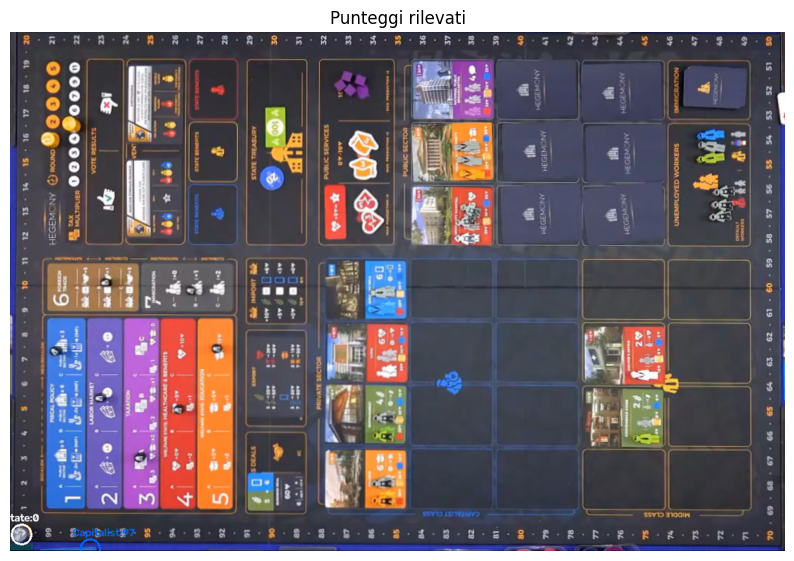

In [92]:
CLASS_DRAW_COLORS = {          # colori BGR per l'annotazione
    "Working":    (0, 0, 255),
    "Capitalist": (255, 100, 0),
    "Middle":     (0, 215, 255),
    "State":      (255, 255, 255),
}


def read_scores(frame, debug=False):
    """Frame grezzo -> ({classe: punteggio}, immagine annotata).
    Ritorna (None, None) se l'allineamento fallisce."""
    aligned = align_to_reference(frame)
    if aligned is None:
        return None, None

    tokens = detect_score_tokens(aligned, debug=debug)

    best = {}
    for t in tokens:
        if t["class"] not in best or t["area"] > best[t["class"]]["area"]:
            best[t["class"]] = t

    annotated = aligned.copy()
    for cls, t in best.items():
        color = CLASS_DRAW_COLORS.get(cls, (0, 255, 0))
        cv2.circle(annotated, t["center"], 14, color, 2)
        cv2.putText(annotated, f"{cls}:{t['score']}",
                    (t["center"][0] - 25, t["center"][1] - 18),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    scores = {cls: t["score"] for cls, t in best.items()}
    return scores, annotated


scores, annotated = read_scores(img, debug=True)
print("\nPunteggi letti:", scores)
show_image(annotated, "Punteggi rilevati")

## 8. Tracking dei punteggi lungo la partita
Applichiamo `read_scores` a tutti i frame della cartella. Se in un frame una classe non viene rilevata (mano sopra il tracciato, disco occluso), manteniamo l'ultimo valore noto (*carry forward*). Il risultato è la timeline dei punteggi.

In [94]:
def track_game(folder, step=1, verbose=True):
    """Analizza i frame della cartella e restituisce la timeline dei punteggi."""
    files = sorted(f for f in os.listdir(folder)
                   if f.lower().endswith((".png", ".jpg", ".jpeg")))
    files = files[::step]

    classes = list(CLASS_DRAW_COLORS.keys())
    timeline = {c: [] for c in classes}
    frames_ok = []
    last_known = {c: None for c in classes}

    for fname in files:
        frame = cv2.imread(os.path.join(folder, fname))
        if frame is None:
            continue
        scores, _ = read_scores(frame)
        if scores is None:
            if verbose:
                print(f"{fname}: allineamento fallito, frame saltato")
            continue

        for c in classes:
            if c in scores:
                last_known[c] = scores[c]
            timeline[c].append(last_known[c])
        frames_ok.append(fname)

        if verbose:
            stato = ", ".join(f"{c}={last_known[c]}" for c in classes)
            print(f"{fname}: {stato}")

    return frames_ok, timeline


frames_ok, timeline = track_game("../dataset/Game_2/", step=1)

[align] score = 0.98
001.png: Working=None, Capitalist=None, Middle=None, State=None
[align] score = 0.94
003.png: Working=None, Capitalist=97, Middle=None, State=0
[align] score = 0.78
005.png: Working=None, Capitalist=79, Middle=None, State=0
[align] score = 0.81
006.png: Working=None, Capitalist=79, Middle=None, State=0
[align] score = 0.82
007.png: Working=None, Capitalist=62, Middle=None, State=0
[align] score = 0.84
008.png: Working=None, Capitalist=62, Middle=None, State=0
[align] score = 0.87
010.png: Working=50, Capitalist=0, Middle=None, State=2
[align] score = 0.79
011.png: Working=1, Capitalist=0, Middle=None, State=9
[align] score = 0.31
013.png: allineamento fallito, frame saltato
[align] score = 0.72
014.png: Working=1, Capitalist=0, Middle=None, State=40
[align] score = 0.78
015.png: Working=29, Capitalist=0, Middle=None, State=40
[align] score = 0.68
016.png: Working=31, Capitalist=0, Middle=None, State=40
[align] score = 0.69
017.png: Working=31, Capitalist=0, Middle=

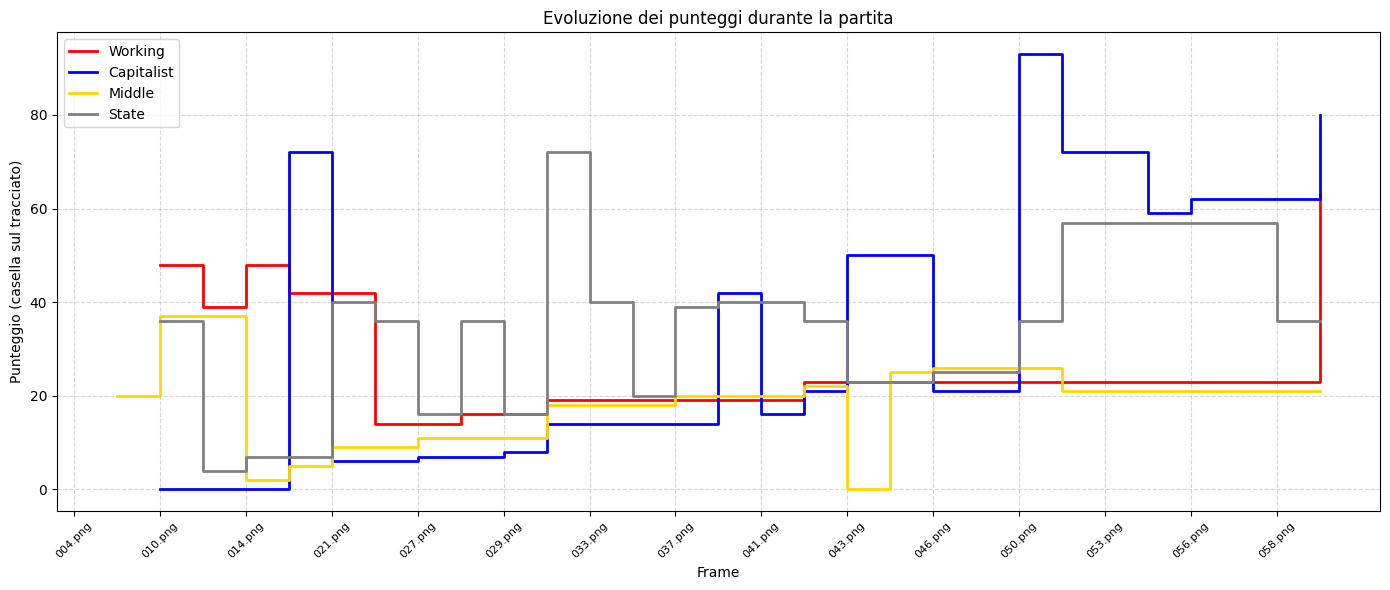

In [83]:
# --- Grafico della timeline ---
PLOT_COLORS = {"Working": "red", "Capitalist": "blue",
               "Middle": "gold", "State": "grey"}

plt.figure(figsize=(14, 6))
x = range(len(frames_ok))
for cls, values in timeline.items():
    vals = [v if v is not None else np.nan for v in values]
    plt.step(x, vals, where="post", label=cls,
             color=PLOT_COLORS.get(cls), linewidth=2)

plt.xticks(list(x)[::max(1, len(frames_ok)//15)],
           [frames_ok[i] for i in range(0, len(frames_ok), max(1, len(frames_ok)//15))],
           rotation=45, fontsize=8)
plt.ylabel("Punteggio (casella sul tracciato)")
plt.xlabel("Frame")
plt.title("Evoluzione dei punteggi durante la partita")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
# Appendice didattica: analisi del frame ed edge detection
Le sezioni seguenti (dal notebook di analisi originale) confrontano tecniche di preprocessing e operatori di edge detection, e mostrano il metodo edge-based di detection usato inizialmente per le pedine. Sono mantenute a scopo di **confronto e documentazione nel report**: la lettura dei punteggi nella pipeline principale usa invece la differenza col riferimento vuoto (sezioni 5–8), più robusta per questo compito.

## A1. Preprocessing

In [ ]:
map_img = aligned.copy()

gray = cv2.cvtColor(map_img, cv2.COLOR_BGR2GRAY)
equalized = cv2.equalizeHist(gray)
blur_gaussian = cv2.GaussianBlur(equalized, (5, 5), 0)
blur_median = cv2.medianBlur(gray, 15)

hist_gray = cv2.calcHist([gray], [0], None, [256], [0, 256])
hist_gaussian = cv2.calcHist([blur_gaussian], [0], None, [256], [0, 256])
hist_median = cv2.calcHist([blur_median], [0], None, [256], [0, 256])

plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1); plt.imshow(gray, cmap='gray'); plt.title("Gray (Original)"); plt.axis("off")
plt.subplot(2, 3, 2); plt.imshow(blur_gaussian, cmap='gray'); plt.title("Equalized + Gaussian Blur"); plt.axis("off")
plt.subplot(2, 3, 3); plt.imshow(blur_median, cmap='gray'); plt.title("Median Filter"); plt.axis("off")
plt.subplot(2, 3, 4); plt.plot(hist_gray, color='black'); plt.title("Histogram: Gray"); plt.xlim([0, 256]); plt.grid(True)
plt.subplot(2, 3, 5); plt.plot(hist_gaussian, color='blue'); plt.title("Histogram: Gaussian Blur"); plt.xlim([0, 256]); plt.grid(True)
plt.subplot(2, 3, 6); plt.plot(hist_median, color='red'); plt.title("Histogram: Median Filter"); plt.xlim([0, 256]); plt.grid(True)
plt.tight_layout()
plt.show()

## A2. Confronto tra operatori di edge detection (implementazioni manuali)

In [ ]:
def robert(img):
    img = img.astype(np.int32).copy()
    out = np.zeros_like(img)
    r, c = img.shape
    kernel = np.array([[-1, -1], [1, 1]])
    for x in range(r - 1):
        for y in range(c - 1):
            out[x, y] = abs((kernel * img[x:x+2, y:y+2]).sum())
    return np.uint8(np.clip(out, 0, 255))

def sobel(img):
    img = img.astype(np.float64)
    r, c = img.shape
    new_image = np.zeros((r, c))
    kX = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    kY = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    for i in range(r - 2):
        for j in range(c - 2):
            gx = abs(np.sum(img[i:i+3, j:j+3] * kX))
            gy = abs(np.sum(img[i:i+3, j:j+3] * kY))
            new_image[i+1, j+1] = (gx**2 + gy**2) ** 0.5
    return np.uint8(np.clip(new_image, 0, 255))

def laplace(img):
    img = img.astype(np.float64)
    r, c = img.shape
    new_image = np.zeros((r, c))
    kL = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
    for i in range(r - 2):
        for j in range(c - 2):
            new_image[i+1, j+1] = abs(np.sum(img[i:i+3, j:j+3] * kL))
    return np.uint8(np.clip(new_image, 0, 255))

print("Processing manual operators (puo' richiedere qualche secondo)...")
img_laplace = laplace(gray)
img_robert  = robert(gray)
img_sobel   = sobel(gray)
print("Processing complete!")

plt.figure(figsize=(15, 10))
plt.subplot(221); plt.title("Original Rectified Image"); plt.imshow(gray, cmap="gray", vmin=0, vmax=255); plt.axis('off')
plt.subplot(222); plt.title("Laplacian Operator"); plt.imshow(img_laplace, cmap="gray", vmin=0, vmax=255); plt.axis('off')
plt.subplot(223); plt.title("Roberts Operator"); plt.imshow(img_robert, cmap="gray", vmin=0, vmax=255); plt.axis('off')
plt.subplot(224); plt.title("Sobel Operator"); plt.imshow(img_sobel, cmap="gray", vmin=0, vmax=255); plt.axis('off')
plt.show()

## A3. Canny e metodo edge-based (per confronto con la pipeline principale)
Il metodo edge-based rileva contorni sia dei numeri stampati sia delle pedine, e deve poi separarli con filtri geometrici: è la sua debolezza strutturale per il tracking dei punteggi, ed è il motivo per cui la pipeline principale usa la differenza col riferimento vuoto.

In [ ]:
edges = cv2.Canny(blur_median, 30, 100)
show_image(edges, "Canny Edges", cmap='gray')

# Confronto diretto: cosa vede Canny vs cosa vede la differenza nel tracciato
mask_canny = cv2.bitwise_and(edges, ring_mask)

frame_blur = cv2.GaussianBlur(map_img, (5, 5), 0)
diff = cv2.absdiff(frame_blur, _empty_blur).max(axis=2).astype(np.uint8)
_, mask_diff = cv2.threshold(cv2.bitwise_and(diff, ring_mask),
                             DIFF_THRESHOLD, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(16, 6))
plt.subplot(121); plt.imshow(mask_canny, cmap='gray')
plt.title("Edge-based: numeri E pedine (da separare coi filtri)"); plt.axis('off')
plt.subplot(122); plt.imshow(mask_diff, cmap='gray')
plt.title("Differenza col vuoto: solo cio' che e' stato aggiunto"); plt.axis('off')
plt.tight_layout()
plt.show()

## Conclusioni
La pipeline finale risponde all'obiettivo del progetto (tracking dei punteggi) combinando i punti di forza dei due lavori:
- dalla parte geometrica: rettifica robusta via **omografia** (ORB + GMS + RANSAC), che rende ogni frame confrontabile pixel per pixel con il riferimento;
- dalla parte di analisi: il modello del **tracciato** e la lettura per **differenza + classificazione colore**, evoluzione della background subtraction abbozzata e del rilevamento a contorni.

Sviluppi possibili: filtro temporale sulla timeline (un punteggio non può diminuire/saltare arbitrariamente tra frame vicini), gestione esplicita dell'occlusione (maschera "mano" da blob grandi), estensione della stessa tecnica alle altre aree del tabellone (`locate_politics`).